# ***Analisis Komparatif Model Linier, Tree-Based Learning, dan Artificial Neural Network untuk Deteksi Opini Publik: Studi Kasus Regulasi Anak 16 Tahun Bermedia Sosial***

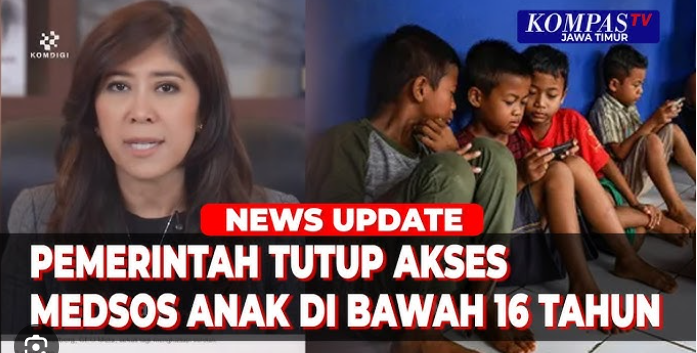

# ***Cara Scraping Komentar Tik-Tok***

In [ ]:
!pip install apify-client pandas

from apify_client import ApifyClient
import pandas as pd

In [ ]:
# Initialize the ApifyClient with your API token
client = ApifyClient("*****") #ganti dengan token Apify anda

# Prepare the Actor input
run_input = {
    "commentsPerPost": 5000,
    "excludePinnedPosts": False,
    "maxRepliesPerComment": 0,
    "postURLs": [
        "https://www.tiktok.com/@liputan6.sctv/video/7616160879809137932?is_from_webapp=1&sender_device=pc&web_id=7553192483641099784",
        "https://www.tiktok.com/@geraldvincentt/video/7616232606824287509?is_from_webapp=1&sender_device=pc&web_id=7553192483641099784",
        "https://www.tiktok.com/@stv_ajaa/video/7615988806377950485?is_from_webapp=1&sender_device=pc&web_id=7553192483641099784"
    ],
    "resultsPerPage": 100
}

# Run the Actor and wait for it to finish
run = client.actor("BDec00yAmCm1QbMEI").call(run_input=run_input)

# =========================================================
# Jalankan Actor
# =========================================================
print("Menjalankan Apify Actor... Mohon tunggu beberapa menit.")
run = client.actor("BDec00yAmCm1QbMEI").call(run_input=run_input)

In [ ]:
# =========================================================
# Ambil hasil dataset dari Apify dan simpan ke list
# =========================================================
results = []
for item in client.dataset(run["defaultDatasetId"]).iterate_items():
    results.append(item)

# =========================================================
# Simpan hasil ke file CSV
# =========================================================
if results:
    df = pd.DataFrame(results)
    df.to_csv("hasil_tiktok_comments.csv", index=False, encoding='utf-8-sig')
    print(f"✅ Data berhasil disimpan ke 'hasil_tiktok_comments.csv' dengan {len(df)} baris.")
else:
    print("⚠️ Tidak ada data yang ditemukan dari scraping.")

In [ ]:
import pandas as pd

data = pd.read_csv("hasil_tiktok_comments.csv")
data.info()
data.head(5)

# ***TEXT PREPROCESSING DATA***

In [ ]:
import pandas as pd

data = pd.read_csv("hasil_tiktok_comments.csv")
data.info()
data.head(5)

In [ ]:
df  = pd.DataFrame(data[['text']])
df.info()
df.head(5)

**PROSES CLEANING**

---



In [ ]:
df.info()
df.head()

In [ ]:
data = df[df.duplicated(subset="text", keep=False)]
data.info()
data.head()

In [ ]:
df.drop_duplicates(subset ="text", inplace = True)

df.info()
data.head()

In [ ]:
import re
import string
import nltk

# Fungsi untuk menghapus URL
def remove_URL(tweet):
    if tweet is not None and isinstance(tweet, str):
        url = re.compile(r'https?://\S+|www\.\S+')
        return url.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus HTML
def remove_html(tweet):
    if tweet is not None and isinstance(tweet, str):
        html = re.compile(r'<.*?>')
        return html.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus emoji
def remove_emoji(tweet):
    if tweet is not None and isinstance(tweet, str):
        emoji_pattern = re.compile("["
            u"\U0001F600-\U0001F64F"  # emoticons
            u"\U0001F300-\U0001F5FF"  # symbols & pictographs
            u"\U0001F680-\U0001F6FF"  # transport & map symbols
            u"\U0001F700-\U0001F77F"  # alchemical symbols
            u"\U0001F780-\U0001F7FF"  # Geometric Shapes Extended
            u"\U0001F800-\U0001F8FF"  # Supplemental Arrows-C
            u"\U0001FA00-\U0001FA6F"  # Chess Symbols
            u"\U0001FA70-\U0001FAFF"  # Symbols and Pictographs Extended-A
            u"\U0001F004-\U0001F0CF"  # Additional emoticons
            u"\U0001F1E0-\U0001F1FF"  # flags
                               "]+", flags=re.UNICODE)
        return emoji_pattern.sub(r'', tweet)
    else:
        return tweet

# Fungsi untuk menghapus simbol
def remove_symbols(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'[^a-zA-Z0-9\s]', '', tweet)
    return tweet

# Fungsi untuk menghapus angka
def remove_numbers(tweet):
    if tweet is not None and isinstance(tweet, str):
        tweet = re.sub(r'\d', '', tweet)
    return tweet

# Fungsi hapus username
def remove_usernames(text):
    if text is not None and isinstance(text, str):
        return re.sub(r'@\w+', '', text)
    else:
        return text

df['cleaning'] = df['text'].apply(lambda x: remove_URL(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_usernames(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_html(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_emoji(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_symbols(x))
df['cleaning'] = df['cleaning'].apply(lambda x: remove_numbers(x))

df.head(5)

**PROSES CASE FOLDING**

---



In [ ]:
def case_folding(text):
    if isinstance(text, str):
        lowercase_text = text.lower()
        return lowercase_text
    else:
        return text

df['case_folding'] = df['cleaning'].apply(case_folding)
df.head(5)

**Normalisasi Kata**

---



In [ ]:
import pandas as pd
import requests
from io import BytesIO

# Fungsi penggantian kata tidak baku
def replace_taboo_words(text, kamus_tidak_baku):
    if isinstance(text, str):
        words = text.split()
        replaced_words = []
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

        for word in words:
            if word in kamus_tidak_baku:
                baku_word = kamus_tidak_baku[word]
                if isinstance(baku_word, str) and all(char.isalpha() for char in baku_word):
                    replaced_words.append(baku_word)
                    kalimat_baku.append(baku_word)
                    kata_diganti.append(word)
                    kata_tidak_baku_hash.append(hash(word))
            else:
                replaced_words.append(word)
        replaced_text = ' '.join(replaced_words)
    else:
        replaced_text = ''
        kalimat_baku = []
        kata_diganti = []
        kata_tidak_baku_hash = []

    return replaced_text, kalimat_baku, kata_diganti, kata_tidak_baku_hash

# Baca dataset kamu (pastikan df sudah tersedia)
data = pd.DataFrame(df[['text','cleaning','case_folding']])
data.head()

In [ ]:
# Unduh dan baca kamus dari GitHub
url = "https://github.com/analysisdatasentiment/kamus_kata_baku/raw/main/kamuskatabaku.xlsx"
response = requests.get(url)
file_excel = BytesIO(response.content)
kamus_data = pd.read_excel(file_excel)

# Buat dictionary dari kamus
kamus_tidak_baku_dict = dict(zip(kamus_data['tidak_baku'], kamus_data['kata_baku']))

In [ ]:
# Terapkan fungsi normalisasi
data[['normalisasi', 'Kata_Baku', 'Kata_Tidak_Baku', 'Kata_Tidak_Baku_Hash']] = data['case_folding'].apply(
    lambda x: pd.Series(replace_taboo_words(x, kamus_tidak_baku_dict))
)

# Ambil kolom yang relevan
df = pd.DataFrame(data[['text','cleaning','case_folding','normalisasi']])
df.head(15)

**TOKENIZATION**

---



In [ ]:
def tokenize(text):
    tokens = text.split()
    return tokens

df['tokenize'] = df['normalisasi'].apply(tokenize)

df.head(5)

**PROSES STOPWORD REMOVAL**

---



In [ ]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

In [ ]:
def remove_stopwords(text):
    return [word for word in text if word not in stop_words]

# Ubah hasil list jadi string
df['stopword removal'] = df['tokenize'].apply(
    lambda x: " ".join(remove_stopwords(x))
)

df.head(5)

In [ ]:
from collections import Counter

all_text = ' '.join(df['stopword removal'].astype(str))
all_text = re.sub(r'[^a-zA-Z\s]', '', all_text.lower())

word_list = all_text.split()
word_freq = Counter(word_list)

sorted_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
df_freq = pd.DataFrame(sorted_freq, columns=['Kata', 'Frekuensi'])

df_freq.to_csv('frekuensi_kata_awal.csv', index=False)
print("✅ File 'frekuensi_kata_awal.csv' berhasil disimpan.")
df_freq.info()
df_freq.head(50)

In [ ]:
hapus_kata = ['ya','tok','deh','wok','we','the','wi','sih','roy','not','nih','cs','y','abang','bang','gue',
              'ya','sih','gue','gua','nih','lo','tuh','all','orang','k','tau','bro',
              'nak','mbak','mu','bu','nuk','ku','ff','pas','ml','iya','dll',
              'ya','om','sih','mbak','gue','ded','gua','mas','tau','bang','nih']

# hapus kata dari teks
df['stopword removal'] = df['stopword removal'].apply(
    lambda x: ' '.join([kata for kata in x.split() if kata not in hapus_kata]))

df['stopword removal'].str.contains('|'.join(hapus_kata)).sum()

In [ ]:
# ---  Membuat kamus kata tidak baku -> kata baku
kamus_tidak_baku = {
    'hp':'handphone',
    'kayak':'kaya',
    'bon':'bobon',
    'sosmed':'sosial media'
}

def perbaiki_kata(teks):
    kata_list = teks.split()
    hasil = [kamus_tidak_baku.get(kata, kata) for kata in kata_list]
    return ' '.join(hasil)

df['stopword removal'] = df['stopword removal'].astype(str).apply(perbaiki_kata)


In [ ]:
from collections import Counter
import re

all_text = ' '.join(df['stopword removal'].astype(str))
all_text = re.sub(r'[^a-zA-Z\s]', '', all_text.lower())

word_list = all_text.split()
word_freq = Counter(word_list)

sorted_freq = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)
df_freq = pd.DataFrame(sorted_freq, columns=['Kata', 'Frekuensi'])

# df_freq.info()
df_freq.head(50)

**WORDCLOUD SETELAH PREPROCESSING**

---



In [ ]:
import pandas as pd
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
import matplotlib.pyplot as plt

# Buat stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp', 'lu','jokowi'])

# WordCloud Before
text_before = ' '.join(
    df['text']
    .astype(str)
    .tolist()
)

wc_before = WordCloud(
    stopwords=stopwords,
    background_color="white",
    max_words=200,
    width=800,
    height=400
).generate(text_before)

# WordCloud After (dari kolom 'stopword removal')
text_after = ' '.join(
    [" ".join(eval(x) if isinstance(x, str) and x.startswith('[') else x.split())
     for x in df['stopword removal'].astype(str)]
)

wc_after = WordCloud(
    stopwords=stopwords,
    background_color="white",
    max_words=200,
    width=800,
    height=400
).generate(text_after)

# Visualisasi side-by-side
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(wc_before, interpolation='bilinear')
plt.axis("off")
plt.title("Before Preprocessing", fontsize=18)

plt.subplot(1, 2, 2)
plt.imshow(wc_after, interpolation='bilinear')
plt.axis("off")
plt.title("After Preprocessing", fontsize=18)

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter
from wordcloud import STOPWORDS
import re

# Set stopwords tambahan
stopwords = set(STOPWORDS)
stopwords.update(['https', 'co', 'RT', '...', 'amp', 'lu'])

# Fungsi helper untuk membersihkan tanda kutip, [ ], , dll
def clean_text_column(series):
    cleaned = []
    for text in series.astype(str):
        # Hapus [ ], tanda petik tunggal/ganda, koma
        text = re.sub(r"[\[\]\'\",]", "", text)
        cleaned.append(text.strip())
    return " ".join(cleaned)

# BEFORE
all_text_before = clean_text_column(df["text"])
words_before = all_text_before.split()
filtered_words_before = [word for word in words_before if word.lower() not in stopwords]
word_counts_before = Counter(filtered_words_before)
top_words_before = word_counts_before.most_common(10)
word_before, count_before = zip(*top_words_before)

# AFTER
all_text_after = clean_text_column(df["stopword removal"])
words_after = all_text_after.split()
filtered_words_after = [word for word in words_after if word.lower() not in stopwords]
word_counts_after = Counter(filtered_words_after)
top_words_after = word_counts_after.most_common(10)
word_after, count_after = zip(*top_words_after)

# Plot berdampingan
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BEFORE Plot
colors_before = plt.cm.Pastel1(range(len(word_before)))
bars1 = axes[0].bar(word_before, count_before, color=colors_before)
axes[0].set_title("Frekuensi Kata Sebelum Preprocessing", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Kata", fontsize=12)
axes[0].set_ylabel("Jumlah", fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
for bar, count in zip(bars1, count_before):
    axes[0].text(bar.get_x() + bar.get_width()/2, count + 1, str(count), ha='center')

# AFTER Plot
colors_after = plt.cm.Pastel2(range(len(word_after)))
bars2 = axes[1].bar(word_after, count_after, color=colors_after)
axes[1].set_title("Frekuensi Kata Setelah Preprocessing", fontsize=14, fontweight='bold')
axes[1].set_xlabel("Kata", fontsize=12)
axes[1].set_ylabel("Jumlah", fontsize=12)
axes[1].tick_params(axis='x', rotation=45)
for bar, count in zip(bars2, count_after):
    axes[1].text(bar.get_x() + bar.get_width()/2, count + 1, str(count), ha='center')

plt.tight_layout()
plt.show()

In [ ]:
df.to_csv('Hasil_Preprocessing_Data.csv',encoding='utf8', index=False);
df.info()
df.head(5)

# ***PELEBELAN DATA METODE LAXICON BASED 2 CLASS***

In [ ]:
import pandas as pd

data = pd.read_csv("Hasil_Preprocessing_Data.csv")
data.info()
data.head()

In [ ]:
data = pd.DataFrame(data[['stopword removal']])
data.head(5)

In [ ]:
import pandas as pd
import requests

# Unduh kamus leksikon positif dan negatif dari GitHub
positive_url = "https://raw.githubusercontent.com/fajri91/InSet/master/positive.tsv"
negative_url = "https://raw.githubusercontent.com/fajri91/InSet/master/negative.tsv"

positive_lexicon = set(pd.read_csv(positive_url, sep="\t", header=None)[0])
negative_lexicon = set(pd.read_csv(negative_url, sep="\t", header=None)[0])

def determine_sentiment(text):
    if isinstance(text, str):
        positive_count = sum(1 for word in text.split() if word in positive_lexicon)
        negative_count = sum(1 for word in text.split() if word in negative_lexicon)
        sentiment_score = positive_count - negative_count
        sentiment = "Negatif" if sentiment_score < 0 else "Positif"
        return sentiment_score, sentiment
    return 0, "Negatif"

data[['Score', 'Sentiment']] = data['stopword removal'].apply(lambda x: pd.Series(determine_sentiment(x)))
data.head(20)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Menghitung jumlah sentimen

sentiment_count = data['Sentiment'].value_counts()
sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=sentiment_count.index, y=sentiment_count.values, palette='pastel')
plt.title('Analisis Sentimen Komentar Tik-Tok Tentang\nLarangan Anak Usia 16 Tahun main Medsos', fontsize=10, pad=20)
plt.xlabel('Class Sentiment', fontsize=10)
plt.ylabel('Jumlah Tweet', fontsize=10)

total = len(data['Sentiment'])

for i, count in enumerate(sentiment_count.values):
    percentage = f'{100 * count / total:.2f}%'
    ax.text(i, count + 0.10, f'{count}\n({percentage})', ha='center', va='bottom')

plt.show()

In [ ]:
data.to_csv('Hasil_Labelling_Data_Inset_Lax.csv',encoding='utf8', index=False)

**WORDCLOUD & FREKUENSI KATA NGRAM**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud

# Ganti dengan path dataset kamu
df = pd.read_csv("Hasil_Labelling_Data_Inset_Lax.csv")

df.info()
df.head()

In [ ]:
# Pastikan tidak ada nilai kosong
df = df.dropna(subset=['stopword removal', 'Sentiment'])
df.head()

In [ ]:
def wordcloud_ngram(data, sentiment_label, ngram_range=(2,3), max_words=1000):
    text_data = data[data['Sentiment'] == sentiment_label]['stopword removal']
    text_data = text_data.dropna()
    text_data = text_data[text_data.str.len() > 0]

    vectorizer = CountVectorizer(ngram_range=ngram_range)
    X = vectorizer.fit_transform(text_data)

    word_freq = dict(zip(
        vectorizer.get_feature_names_out(),
        X.sum(axis=0).A1
    ))

    # filter frekuensi kecil
    word_freq = {k: v for k, v in word_freq.items() if v > 2}

    wc = WordCloud(
        width=1000,
        height=500,
        background_color='white',
        max_words=max_words,
        prefer_horizontal=0.9,
        relative_scaling=0.5,
        collocations=False,
        min_font_size=8,
        max_font_size=120,
        scale=5
    ).generate_from_frequencies(word_freq)

    plt.figure(figsize=(6,4))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'WordCloud {ngram_range[0]}-gram Sentimen {sentiment_label}', fontsize=14)
    plt.show()

wordcloud_ngram(df, 'Positif', ngram_range=(3,3))
print()
wordcloud_ngram(df, 'Negatif', ngram_range=(3,3))

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_ngram(data, sentiment_label,
                   ngram_range=(2,2),
                   top_n=20,
                   color='blue'):

    text_data = data[data['Sentiment'] == sentiment_label]['stopword removal']

    vectorizer = CountVectorizer(ngram_range=ngram_range)
    X = vectorizer.fit_transform(text_data)

    freq_df = pd.DataFrame({
        'ngram': vectorizer.get_feature_names_out(),
        'frequency': X.sum(axis=0).A1
    }).sort_values(by='frequency', ascending=False).head(top_n)

    plt.figure(figsize=(8,4))
    bars = plt.barh(freq_df['ngram'], freq_df['frequency'], color=color)
    plt.gca().invert_yaxis()

    plt.xlabel('Frekuensi')
    plt.title(f'Top {top_n} {ngram_range[0]}-gram Sentimen {sentiment_label}')

    # 🔢 Label tepat di ujung bar
    for bar in bars:
        width = bar.get_width()
        plt.text(
            width,                              # tepat di ujung bar
            bar.get_y() + bar.get_height()/2,
            f'{int(width)}',
            va='center',
            ha='left',                          # teks keluar ke kanan
            fontsize=9
        )

    plt.tight_layout()
    plt.show()


# Pemanggilan
plot_top_ngram(df, 'Positif', ngram_range=(3,3), color='green')
print()
plot_top_ngram(df, 'Negatif', ngram_range=(3,3), color='red')

# ***Inset Laxicon Based | Regresi Logistik, SVM, KNN, Naive Bayes, Random Forest, Decision Tree, dan Neural Network***

In [ ]:
import pandas as pd

file_path = 'Hasil_Labelling_Data_Inset_Lax.csv'
data = pd.read_csv(file_path)

data.info()
data.head()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer

cleaned_data = data.dropna(subset=['stopword removal'])

X = cleaned_data['stopword removal']
y = cleaned_data['Sentiment']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)

print("Jumlah data latih:", len(X_train))
print("Jumlah data uji:", len(X_test))
print('===========================')

In [ ]:
import matplotlib.pyplot as plt


train_size = len(X_train)
test_size = len(X_test)

plt.figure(figsize=(4, 3))
bars = plt.bar(['Data Training', 'Data Testing'], [train_size, test_size], color=['blue', 'orange'])

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height} ({height / (train_size + test_size) * 100:.2f}%)',
             ha='center', va='bottom')

plt.title('Jumlah Data Latih dan Data Uji')
plt.xlabel('Jenis Data')
plt.ylabel('Jumlah Data')
plt.show()


In [ ]:
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

X_train_vec.shape, X_test_vec.shape

print("Jumlah fitur (kolom) setelah vektorisasi:", X_train_vec.shape[1])
print("Jumlah fitur (kolom) setelah vektorisasi:", X_test_vec.shape[1])

In [ ]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt

# =========================================
# Inisialisasi Model
# =========================================
models = {
    "SVM": SVC(kernel='linear', random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Neural Network": MLPClassifier(random_state=42, hidden_layer_sizes=(100,), max_iter=500),
    "Logistic Regression": LogisticRegression(max_iter=500, random_state=42)
}

# =========================================
# Pelatihan & Evaluasi Model
# =========================================
results = {}

for model_name, model in models.items():
    model.fit(X_train_vec, y_train)
    y_pred = model.predict(X_test_vec)
    results[model_name] = {
        "accuracy": accuracy_score(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred, output_dict=True),
        "confusion_matrix": confusion_matrix(y_test, y_pred)
    }


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

for model_name, result in results.items():
    fig, ax = plt.subplots(figsize=(4, 4))
    sns.heatmap(
        result["confusion_matrix"],
        annot=True,
        fmt='d',
        cmap="YlGnBu",
        cbar=False,
        xticklabels=['Negatif','Positif'],
        yticklabels=['Negatif','Positif'],
        ax=ax,
        square=True,
        linewidths=0.5
    )
    print(f"\nConfusion Matrix for {model_name}:")
    ax.set_title(f"{model_name} Confusion Matrix", fontsize=12)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("Actual", fontsize=12)


    plt.tight_layout()
    plt.show()


In [ ]:
import matplotlib.pyplot as plt

# Urutkan berdasarkan nilai akurasi (dari besar ke kecil)
accuracies = {model: result['accuracy'] for model, result in results.items()}
sorted_accuracies = dict(sorted(accuracies.items(), key=lambda item: item[1], reverse=True))

# Warna terang cerah (bright colors)
bright_colors = [
    'lightskyblue', 'lightcoral', 'palegreen', 'khaki',
    'plum', 'lightsalmon', 'mediumturquoise', 'wheat'
]

# Sesuaikan jumlah warna dengan jumlah model
num_models = len(sorted_accuracies)
colors = bright_colors[:num_models] if num_models <= len(bright_colors) else bright_colors * (num_models // len(bright_colors) + 1)

plt.figure(figsize=(8, 5))

# Buat bar horizontal dengan warna terang
bars = plt.barh(
    list(sorted_accuracies.keys()),
    list(sorted_accuracies.values()),
    color=colors[:num_models]
)

# Tambahkan nilai akurasi di setiap bar
for bar in bars:
    accuracy = bar.get_width()
    plt.text(
        accuracy + 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{accuracy:.2f} ({accuracy * 100:.1f}%)',
        va='center',
        fontsize=10
    )

plt.title("Perbandingan Akurasi Model")
plt.xlabel("Akurasi")
plt.xlim(0, 2)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [ ]:
from IPython.display import display

for model_name, result in results.items():
    print(f"\nClassification Report for {model_name}:")

    report_df = pd.DataFrame(result['classification_report']).transpose()

    styled_df = report_df.style.background_gradient(cmap="coolwarm")
    styled_df = styled_df.format(precision=3)
    display(styled_df)